In [1]:
import sys
import os
sys.path.append(os.path.abspath("../src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Loading dataset
# News Headline
news = pd.read_json("../data/raw/newsheadline/Sarcasm_Headlines_Dataset_v2.json", lines=True)

news.head()

,is_sarcastic,headline,article_link
0,1,thirtysomething scientists unveil doomsday clo...,https://www.theonion.com/thirtysomething-scien...
1,0,dem rep. totally nails why congress is falling...,https://www.huffingtonpost.com/entry/donna-edw...
2,0,eat your veggies: 9 deliciously different recipes,https://www.huffingtonpost.com/entry/eat-your-...
3,1,inclement weather prevents liar from getting t...,https://local.theonion.com/inclement-weather-p...
4,1,mother comes pretty close to using word 'strea...,https://www.theonion.com/mother-comes-pretty-c...


In [5]:
# Reddit dataset
reddit_train = pd.read_csv("../data/raw/sarc_reddit/train-balanced-sarcasm.csv")
reddit_test_bal = pd.read_csv("../data/raw/sarc_reddit/test-balanced.csv")
reddit_test_unbal = pd.read_csv("../data/raw/sarc_reddit/test-unbalanced.csv")

reddit = pd.concat([reddit_train, reddit_test_bal, reddit_test_unbal], ignore_index=True)
reddit.head()

,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment,7x7dx,c07nkao c07nk63,1 0,7u1ht,c07em3g,1
0,0.0,NC and NH.,Trumpbart,politics,2.0,-1.0,-1.0,2016-10,2016-10-16 23:55:23,"Yeah, I get that argument. At this point, I'd ...",NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,You do know west teams play against west teams...,Shbshb906,nba,-4.0,-1.0,-1.0,2016-11,2016-11-01 00:24:10,The blazers and Mavericks (The wests 5 and 6 s...,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,"They were underdogs earlier today, but since G...",Creepeth,nfl,3.0,3.0,0.0,2016-09,2016-09-22 21:45:37,They're favored to win.,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,"This meme isn't funny none of the ""new york ni...",icebrotha,BlackPeopleTwitter,-8.0,-1.0,-1.0,2016-10,2016-10-18 21:03:47,deadass don't kill my buzz,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,I could use one of those tools.,cush2push,MaddenUltimateTeam,6.0,-1.0,-1.0,2016-12,2016-12-30 17:00:13,Yep can confirm I saw the tool they use for th...,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Inspection of Dataset
# News Headline
news.info()
news.head()
news['is_sarcastic'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   is_sarcastic  28619 non-null  int64 
 1   headline      28619 non-null  object
 2   article_link  28619 non-null  object
dtypes: int64(1), object(2)
memory usage: 670.9+ KB


is_sarcastic
0    14985
1    13634
Name: count, dtype: int64

In [8]:
# Inspection of Dataset
# SARC Reddit Dataset
reddit.info()
reddit.head()
reddit['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1107155 entries, 0 to 1107154
Data columns (total 16 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   label            1010826 non-null  float64
 1   comment          1010771 non-null  object 
 2   author           1010826 non-null  object 
 3   subreddit        1010826 non-null  object 
 4   score            1010826 non-null  float64
 5   ups              1010826 non-null  float64
 6   downs            1010826 non-null  float64
 7   date             1010826 non-null  object 
 8   created_utc      1010826 non-null  object 
 9   parent_comment   1010826 non-null  object 
 10  7x7dx            32332 non-null    object 
 11  c07nkao c07nk63  32332 non-null    object 
 12  1 0              32332 non-null    object 
 13  7u1ht            63997 non-null    object 
 14  c07em3g          63997 non-null    object 
 15  1                63997 non-null    object 
dtypes: float64(4), obj

label
0.0    505413
1.0    505413
Name: count, dtype: int64

In [9]:
# Standardize Datasets
# News Headline dataset
news_df = news.rename(columns={
    "headline": "text",
    "is_sarcastic": "label"
})

news_df["source"] = "news"
news_df = news_df[["text", "label", "source"]]

In [10]:
# SARC Reddit
reddit_df = reddit.rename(columns={
    "comment": "text",   # adjust if column name differs
    "label": "label"
})

reddit_df["source"] = "reddit"
reddit_df = reddit_df[["text", "label", "source"]]

In [12]:
# Combination of Dataset
combined_df = pd.concat([news_df, reddit_df], ignore_index=True)
combined_df.head()

,text,label,source
0,thirtysomething scientists unveil doomsday clo...,1.0,news
1,dem rep. totally nails why congress is falling...,0.0,news
2,eat your veggies: 9 deliciously different recipes,0.0,news
3,inclement weather prevents liar from getting t...,1.0,news
4,mother comes pretty close to using word 'strea...,1.0,news


## Cross-Dataset Differences

Instead of combining datasets, this project evaluates **how models trained on one dataset perform on another**.

### Key Differences Between Datasets:

| Feature        | News Headlines       | Reddit Comments        |
|----------------|---------------------|------------------------|
| Length         | Short               | Highly variable        |
| Style          | Formal              | Informal               |
| Noise          | Low                 | High                   |
| Context        | Self-contained      | Context-dependent      |

### Key Insight:
These differences represent a **domain shift**, which is expected to significantly impact model performance.

### Research Focus:
This project aims to answer:
- Can sarcasm detection models generalize across domains?
- Are sarcasm patterns **universal**, or **dataset-specific**?

### Expected Outcome:
- Performance will likely **drop when testing on a different dataset**
- This drop quantifies the **generalization gap**

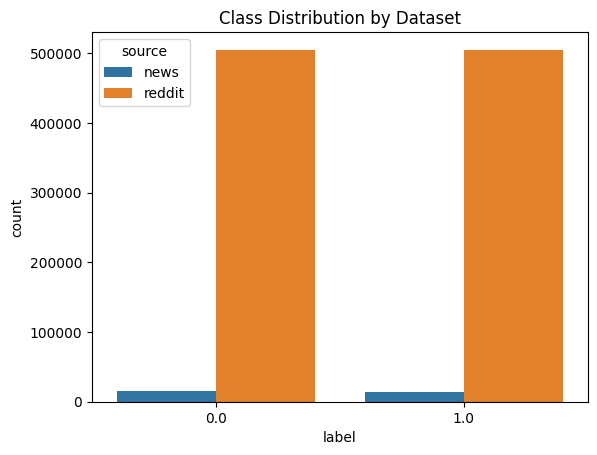

In [13]:
# Class Distribution
sns.countplot(data=combined_df, x="label", hue="source")
plt.title("Class Distribution by Dataset")
plt.show()

## Class Distribution Analysis

From the class distribution plot, both datasets (News and Reddit) are **well balanced** between sarcastic (1) and non-sarcastic (0) labels.

However, there is a **significant difference in dataset size**:
- Reddit contains **over 500,000 samples per class**
- News contains only around **25,000–30,000 samples per class**

### Key Insights:
- There is **no class imbalance issue within each dataset**, which ensures fair training and evaluation.
- The **large size difference** means models trained on Reddit may learn more diverse patterns compared to News.

### Implication for This Project:
Since the goal is **cross-dataset generalization**:
- A model trained on Reddit may perform well due to its scale and diversity
- A model trained on News may struggle when tested on Reddit due to limited exposure

### Experimental Importance:
This setup allows us to evaluate:
- How well sarcasm detection models **transfer across domains**
- Whether sarcasm patterns are **dataset-specific or generalizable**

In [14]:
# Missing Values
combined_df.isnull().sum()

text      96384
label     96329
source        0
dtype: int64

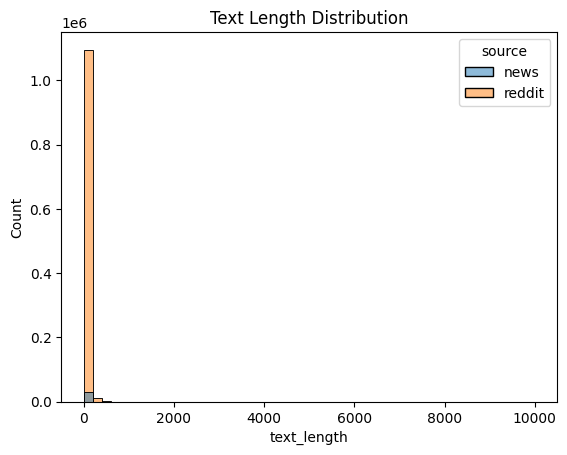

In [15]:
# Text Length Analysis
combined_df["text_length"] = combined_df["text"].astype(str).apply(len)

sns.histplot(data=combined_df, x="text_length", hue="source", bins=50)
plt.title("Text Length Distribution")
plt.show()

## Text Length Distribution Analysis

The text length distribution highlights a **major domain difference** between the datasets:

- **News headlines**:
  - Short, consistent length
  - Typically under 100 characters
  - Structured and formal

- **Reddit comments**:
  - Highly variable length
  - Can be extremely long (up to thousands of characters)
  - Informal and conversational

### Key Insights:
- Reddit data exhibits a **long-tail distribution**, with a few very long texts.
- News data is **uniform and compact**, making it easier to model.

### Implication for Cross-Dataset Generalization:
- A model trained on News:
  - Will learn from **short, clean text**
  - May struggle with **long, noisy Reddit comments**

- A model trained on Reddit:
  - Will see a wide range of text lengths
  - May generalize better to shorter texts like News headlines

### Modeling Consideration:
- A consistent **maximum sequence length** (e.g., 100–200 tokens) should be applied across datasets
- Truncation strategies must be carefully designed to avoid losing important context in Reddit data

In [16]:
# Sample Text Inspection
combined_df[combined_df["label"] == 1]["text"].sample(5)
combined_df[combined_df["label"] == 0]["text"].sample(5)

855922    Barry Melrose picked you to beat the Avs... so...
441429    That would require a miracle, as you HAVE to t...
924850                                          My ringtone
525777                                     Pjango Unchained
610810    Have you tried being filthy rich, famous, or o...
Name: text, dtype: object

## Sample Text Inspection

Inspection of sample texts reveals clear differences in how sarcasm is expressed across datasets.

### Observations:
- Sarcasm often appears as:
  - Subtle contradictions
  - Dry or understated tone
  - Context-dependent meaning

- Reddit-specific characteristics:
  - Informal language, slang, emojis
  - Conversational tone
  - Context-heavy sarcasm

- News-specific characteristics:
  - Short, self-contained statements
  - More structured and less noisy

## Key Takeaways

- Both datasets are **balanced**, ensuring fair evaluation.
- There are **major differences in text length, style, and noise levels**.
- Sarcasm is **subtle and context-dependent**, making it difficult to detect.
- The datasets represent **different domains**, introducing a clear domain shift.